# Clasificación Automática de Modulación (AMC)
## Dataset RML2016.10a + Red Neuronal VT-CNN2

Este notebook ha sido actualizado para funcionar con **Python 3** y las versiones modernas de **TensorFlow 2.x / Keras**, replicando el comportamiento y la estructura del código original en Theano.


In [ ]:
# Importamos las librerías necesarias
import os, random
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Reshape, Dense, Dropout, Activation, Flatten, Conv2D, ZeroPadding2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

%matplotlib inline


## Configuración y Carga del Dataset
Montamos Google Drive para poder acceder a los archivos del proyecto y cargamos el archivo `.pkl`.

**Dato clave:** Es crítico usar `encoding='latin1'` en `pickle.load()` ya que el dataset RML2016.10a fue serializado originalmente en un entorno de Python 2.


In [ ]:
from google.colab import drive

# 1. Montamos Google Drive (te pedirá autorización la primera vez)
drive.mount('/content/drive')

# 2. Definimos la ruta exacta y cargamos el archivo
dataset_path = '/content/drive/MyDrive/Sync GD/TESIS/Colab/Datasets/RML2016.10a_dict.pkl/RML2016.10a_dict.pkl'
with open(dataset_path, 'rb') as f:
    Xd = pickle.load(f, encoding='latin1')

print("Dataset cargado correctamente.")


Mounted at /content/drive
Dataset cargado correctamente.


## Procesamiento y Partición de los Datos
En esta sección extraemos las señales y sus etiquetas correspondientes (tipo de modulación y SNR), agrupándolas en matrices de NumPy. Luego, particionamos aleatoriamente los datos en un conjunto de entrenamiento (50%) y prueba (50%), y convertimos las etiquetas al formato matricial 'one-hot'.

**Actualización:** Se ha adaptado el código de `map()` envolviéndolo en un iterador de lista `list(...)` ya que en Python 3 este método retorna un objeto iterador en lugar de una lista.


In [ ]:
snrs, mods = map(lambda j: sorted(list(set(map(lambda x: x[j], Xd.keys())))), [1,0])
snrs = list(snrs)
mods = list(mods)

X = []
lbl = []
for mod in mods:
    for snr in snrs:
        X.append(Xd[(mod, snr)])
        for i in range(Xd[(mod, snr)].shape[0]):
            lbl.append((mod, snr))
X = np.vstack(X)

# Fijamos la semilla para reproducibilidad exacta
np.random.seed(2016)
n_examples = X.shape[0]
n_train = int(n_examples * 0.5)
train_idx = np.random.choice(range(0, n_examples), size=n_train, replace=False)
test_idx = list(set(range(0, n_examples)) - set(train_idx))

X_train = X[train_idx]
X_test =  X[test_idx]

def to_onehot(yy):
    yy1 = np.zeros([len(yy), max(yy)+1])
    yy1[np.arange(len(yy)), yy] = 1
    return yy1

Y_train = to_onehot(list(map(lambda x: mods.index(lbl[x][0]), train_idx)))
Y_test = to_onehot(list(map(lambda x: mods.index(lbl[x][0]), test_idx)))

in_shp = list(X_train.shape[1:])
print("Dimensiones de entrada:", X_train.shape, in_shp)
classes = mods


Dimensiones de entrada: (110000, 2, 128) [2, 128]


## Construcción del Modelo de Red Neuronal (VT-CNN2)
Construimos el modelo adaptando el código original a la sintaxis moderna de Keras de TensorFlow 2.x.

**Nota de Actualización:** Es de vital importancia usar el parámetro explícito `data_format='channels_first'` en las capas `Conv2D` y `ZeroPadding2D`. Originalmente, el backend Theano procesaba los datos con los canales en la primera dimensión `(1, 2, 128)`. Hacer este ajuste asegura que TensorFlow replique la misma estructura, interpretando el 1 como canal y 2x128 como alto y ancho, logrando coincidir exactamente en el mismo número de parámetros originales (2,830,427).


In [ ]:
dr = 0.5 # tasa de dropout (%)
model = Sequential()

# Reshape de entrada (batch, channels, height, width) -> (1, 2, 128)
model.add(Reshape([1] + in_shp, input_shape=in_shp))

# Capa Convolucional 1
model.add(ZeroPadding2D(padding=(0, 2), data_format='channels_first'))
model.add(Conv2D(256, (1, 3), padding='valid', activation="relu", name="conv1", kernel_initializer='glorot_uniform', data_format='channels_first'))
model.add(Dropout(dr))

# Capa Convolucional 2
model.add(ZeroPadding2D(padding=(0, 2), data_format='channels_first'))
model.add(Conv2D(80, (2, 3), padding="valid", activation="relu", name="conv2", kernel_initializer='glorot_uniform', data_format='channels_first'))
model.add(Dropout(dr))

# Capas Densas
model.add(Flatten())
model.add(Dense(256, activation='relu', kernel_initializer='he_normal', name="dense1"))
model.add(Dropout(dr))
model.add(Dense(len(classes), kernel_initializer='he_normal', name="dense2"))
model.add(Activation('softmax'))
model.add(Reshape([len(classes)]))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 1, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 1, 2, 132)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 256, 2, 130)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 2, 130)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_1                │ (None, 256, 2, 134)    │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 80, 1, 132)     │       122,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 80, 1, 132)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10560)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │     2,703,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 11)             │         2,827 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 11)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,830,427 (10.80 MB)

 Trainable params: 2,830,427 (10.80 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del Modelo
Entrenamos la red convolucional.

**Actualizaciones de sintaxis:** Las sentencias de Keras antiguo como `nb_epoch` han sido actualizadas a `epochs`. El argumento descontinuado `show_accuracy` ha sido removido a favor de la definición en `model.compile()`. El callback de `EarlyStopping` detendrá el entrenamiento si el valor de `val_loss` deja de mejorar luego de 5 épocas, guardando los mejores pesos en un archivo h5.


In [ ]:
nb_epoch = 100     # número de épocas
batch_size = 1024  # tamaño del lote (batch size)
filepath = 'convmodrecnets_CNN2_0.5.wts.h5'

history = model.fit(X_train,
    Y_train,
    batch_size=batch_size,
    epochs=nb_epoch,
    verbose=2,
    validation_data=(X_test, Y_test),
    callbacks = [
        ModelCheckpoint(filepath, monitor='val_loss', verbose=0, save_best_only=True, mode='auto'),
        EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='auto')
    ])

# Recargamos los mejores pesos tras el entrenamiento
model.load_weights(filepath)


Epoch 1/100


108/108 - 28s - 263ms/step - accuracy: 0.1484 - loss: 2.2521 - val_accuracy: 0.2155 - val_loss: 2.0991
Epoch 2/100


108/108 - 9s - 82ms/step - accuracy: 0.2564 - loss: 2.0138 - val_accuracy: 0.2906 - val_loss: 1.8965
Epoch 3/100


108/108 - 9s - 82ms/step - accuracy: 0.3011 - loss: 1.8753 - val_accuracy: 0.3503 - val_loss: 1.7611
Epoch 4/100


108/108 - 9s - 83ms/step - accuracy: 0.3380 - loss: 1.7663 - val_accuracy: 0.3826 - val_loss: 1.6685
Epoch 5/100


...

108/108 - 10s - 90ms/step - accuracy: 0.4600 - loss: 1.4011 - val_accuracy: 0.4951 - val_loss: 1.3160
Epoch 18/100
108/108 - 10s - 90ms/step - accuracy: 0.4624 - loss: 1.3973 - val_accuracy: 0.4865 - val_loss: 1.3271
Epoch 19/100
108/108 - 10s - 91ms/step - accuracy: 0.4648 - loss: 1.3920 - val_accuracy: 0.4907 - val_loss: 1.3250
Epoch 20/100
108/108 - 10s - 95ms/step - accuracy: 0.4665 - loss: 1.3843 - val_accuracy: 0.4897 - val_loss: 1.3225
Epoch 21/100


108/108 - 10s - 92ms/step - accuracy: 0.4674 - loss: 1.3834 - val_accuracy: 0.4936 - val_loss: 1.3070
Epoch 22/100
108/108 - 10s - 91ms/step - accuracy: 0.4663 - loss: 1.3857 - val_accuracy: 0.4952 - val_loss: 1.3094
Epoch 23/100


108/108 - 10s - 92ms/step - accuracy: 0.4695 - loss: 1.3736 - val_accuracy: 0.5006 - val_loss: 1.2939
Epoch 24/100
108/108 - 10s - 91ms/step - accuracy: 0.4701 - loss: 1.3767 - val_accuracy: 0.4967 - val_loss: 1.3031
Epoch 25/100
108/108 - 10s - 91ms/step - accuracy: 0.4726 - loss: 1.3651 - val_accuracy: 0.4963 - val_loss: 1.3016
Epoch 26/100
108/108 - 10s - 91ms/step - accuracy: 0.4728 - loss: 1.3641 - val_accuracy: 0.4945 - val_loss: 1.3047
Epoch 27/100


108/108 - 10s - 92ms/step - accuracy: 0.4729 - loss: 1.3659 - val_accuracy: 0.4993 - val_loss: 1.2876
Epoch 28/100
108/108 - 10s - 91ms/step - accuracy: 0.4763 - loss: 1.3574 - val_accuracy: 0.4978 - val_loss: 1.3076
Epoch 29/100


108/108 - 10s - 92ms/step - accuracy: 0.4769 - loss: 1.3540 - val_accuracy: 0.5028 - val_loss: 1.2862
Epoch 30/100
108/108 - 10s - 91ms/step - accuracy: 0.4792 - loss: 1.3509 - val_accuracy: 0.4983 - val_loss: 1.3016
Epoch 31/100
108/108 - 10s - 91ms/step - accuracy: 0.4791 - loss: 1.3473 - val_accuracy: 0.4958 - val_loss: 1.3008
Epoch 32/100
108/108 - 10s - 91ms/step - accuracy: 0.4798 - loss: 1.3446 - val_accuracy: 0.4981 - val_loss: 1.2931
Epoch 33/100
108/108 - 10s - 91ms/step - accuracy: 0.4794 - loss: 1.3512 - val_accuracy: 0.4985 - val_loss: 1.2896
Epoch 34/100
108/108 - 10s - 91ms/step - accuracy: 0.4810 - loss: 1.3407 - val_accuracy: 0.4973 - val_loss: 1.2971


## Evaluación, métricas y exportación de figuras (formato PDF para LaTeX)

A partir de aquí **no se modifica la red ni sus hiperparámetros**: solo se cambia el
**formato de salida**. Esta sección replica exactamente el estilo de figuras de
`graficar_resultados.py` (tipografía *serif*, mapa de color azul `#f7fbff→#08306b`,
matrices normalizadas por fila con anotaciones en %, línea de azar 1/11, etc.) y el
**reporte textual** de métricas en el espíritu de `diagnostico_features.py`.

Se generan, dentro de `figs_obj3/`, los PDF vectoriales:
`vtcnn2_loss.pdf`, `vtcnn2_error_vs_epoca.pdf`, `vtcnn2_accuracy_vs_epoca.pdf`,
`vtcnn2_acc_vs_snr.pdf`, `vtcnn2_confusion_global.pdf`,
`vtcnn2_confusion_snr18.pdf` (y una por cada SNR en `confusion_por_snr/`),
`vtcnn2_confusion_grid_snr.pdf`, `vtcnn2_class_metrics.pdf` y
`vtcnn2_metrics_by_snr.pdf`. Además se guardan los CSV crudos en `resultados_csv/`
(compatibles con `graficar_resultados.py`).

In [ ]:
# =====================================================================
# 0) Estilo y carpetas de salida  (idéntico a graficar_resultados.py)
# =====================================================================
import os, csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "figure.dpi": 150,
})
BLUES = LinearSegmentedColormap.from_list("blues", ["#f7fbff", "#08306b"])

OUTDIR = "figs_obj3"            # PDFs vectoriales para LaTeX
CSVDIR = "resultados_csv"       # CSVs crudos (compatibles con graficar_resultados.py)
SNRDIR = os.path.join(OUTDIR, "confusion_por_snr")
for d in (OUTDIR, CSVDIR, SNRDIR):
    os.makedirs(d, exist_ok=True)

def snr_tag(snr):
    """-20 -> 'm20' ; 18 -> '18'  (igual que graficar_resultados.py)."""
    return f"m{abs(int(snr))}" if snr < 0 else f"{int(snr)}"

print("Carpetas listas:", OUTDIR, "y", CSVDIR)


Carpetas listas: figs_obj3 y resultados_csv


In [ ]:
# =====================================================================
# 1) Predicciones y cálculo de todas las métricas (una sola pasada)
# =====================================================================
test_Y_hat = model.predict(X_test, batch_size=batch_size, verbose=0)
y_true = np.argmax(Y_test, axis=1)
y_pred = np.argmax(test_Y_hat, axis=1)
n_cls  = len(classes)

# SNR de cada muestra del conjunto de prueba
test_SNRs_arr = np.array([lbl[i][1] for i in test_idx])

def confusion_counts(yt, yp):
    M = np.zeros((n_cls, n_cls), dtype=np.int64)
    for t, p in zip(yt, yp):
        M[t, p] += 1
    return M

def prf_from_conf(M):
    """Devuelve precision, recall y F1 por clase a partir de conteos."""
    tp = np.diag(M).astype(float)
    pred_sum = M.sum(axis=0).astype(float)
    real_sum = M.sum(axis=1).astype(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        prec = np.where(pred_sum > 0, tp / pred_sum, 0.0)
        rec  = np.where(real_sum > 0, tp / real_sum, 0.0)
        f1   = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)
    return prec, rec, f1

# --- Matriz global ---
conf_global = confusion_counts(y_true, y_pred)
acc_global  = np.trace(conf_global) / conf_global.sum()
prec_g, rec_g, f1_g = prf_from_conf(conf_global)

# --- Por nivel de SNR ---
conf_by_snr, acc_by_snr, metrics_by_snr = {}, {}, {}
for snr in snrs:
    m = test_SNRs_arr == snr
    Ms = confusion_counts(y_true[m], y_pred[m])
    conf_by_snr[snr] = Ms
    s = Ms.sum()
    acc_by_snr[snr] = (np.trace(Ms) / s) if s > 0 else 0.0
    p, r, f = prf_from_conf(Ms)
    metrics_by_snr[snr] = dict(precision_macro=p.mean(), recall_macro=r.mean(),
                               f1_macro=f.mean(), accuracy=acc_by_snr[snr])

print(f"Accuracy global = {acc_global*100:.2f}%")
print(f"Precision macro = {prec_g.mean()*100:.2f}%  "
      f"Recall macro = {rec_g.mean()*100:.2f}%  F1 macro = {f1_g.mean()*100:.2f}%")


Accuracy global = 50.28%
Precision macro = 59.17%  Recall macro = 50.38%  F1 macro = 50.54%


In [ ]:
# =====================================================================
# 2) Reporte textual de métricas (estilo diagnostico_features.py)
# =====================================================================
print("=" * 64)
print(f"VT-CNN2  |  Clases: {n_cls}  |  Azar (1/n) = {100.0/n_cls:.2f}%")
print(f"Accuracy global en test = {acc_global*100:.2f}%")
print("=" * 64)

print("\n[1] Métricas por clase (precision / recall / F1):")
print(f"  {'clase':<8} {'prec':>7} {'recall':>7} {'F1':>7}")
for i, c in enumerate(classes):
    print(f"  {c:<8} {prec_g[i]*100:6.2f}% {rec_g[i]*100:6.2f}% {f1_g[i]*100:6.2f}%")
print(f"  {'MACRO':<8} {prec_g.mean()*100:6.2f}% {rec_g.mean()*100:6.2f}% {f1_g.mean()*100:6.2f}%")

print("\n[2] Matriz de confusión global (conteos):")
header = "real\\pred " + " ".join(f"{c[:4]:>5}" for c in classes)
print("  " + header)
for i, c in enumerate(classes):
    row = " ".join(f"{conf_global[i, j]:5d}" for j in range(n_cls))
    print(f"  {c:<8} {row}")

print("\n[3] Accuracy por nivel de SNR:")
for snr in snrs:
    print(f"  SNR = {snr:>3} dB -> accuracy = {acc_by_snr[snr]*100:6.2f}%")


VT-CNN2  |  Clases: 11  |  Azar (1/n) = 9.09%
Accuracy global en test = 50.28%

[1] Métricas por clase (precision / recall / F1):
  clase       prec  recall      F1
  8PSK      39.57%  23.09%  29.16%
  AM-DSB    53.60%  69.31%  60.45%
  AM-SSB    25.73%  94.53%  40.46%
  BPSK      84.34%  58.55%  69.12%
  CPFSK     72.70%  59.73%  65.58%
  GFSK      75.48%  61.98%  68.06%
  PAM4      93.04%  63.53%  75.50%
  QAM16     42.94%  20.97%  28.18%
  QAM64     54.16%  51.10%  52.58%
  QPSK      44.49%  32.46%  37.53%
  WBFM      64.84%  18.93%  29.30%
  MACRO     59.17%  50.38%  50.54%

[2] Matriz de confusión global (conteos):
  real\pred  8PSK  AM-D  AM-S  BPSK  CPFS  GFSK  PAM4  QAM1  QAM6  QPSK  WBFM
  8PSK      2334    87  3420    37   622   225    16   306   166  2874    22
  AM-DSB       8  6833  2330    12    22   159     8     4     0    11   472
  AM-SSB      33   221  9424    39    47   111    17     6     0    36    35
  BPSK        75    85  3323  5851   105    92   308     5     

In [ ]:
# =====================================================================
# 3) Escritura de CSVs crudos (compatibles con graficar_resultados.py)
# =====================================================================
def write_confusion_csv(path, M):
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow([""] + list(classes))
        for i, c in enumerate(classes):
            w.writerow([c] + [int(v) for v in M[i]])

write_confusion_csv(os.path.join(CSVDIR, "confusion_global.csv"), conf_global)
for snr in snrs:
    write_confusion_csv(os.path.join(CSVDIR, f"confusion_snr_{snr_tag(snr)}.csv"),
                        conf_by_snr[snr])

with open(os.path.join(CSVDIR, "accuracy_vs_snr.csv"), "w", newline="") as f:
    w = csv.writer(f); w.writerow(["snr", "accuracy"])
    for snr in snrs:
        w.writerow([snr, f"{acc_by_snr[snr]:.6f}"])

with open(os.path.join(CSVDIR, "class_metrics.csv"), "w", newline="") as f:
    w = csv.writer(f); w.writerow(["class", "precision", "recall", "f1"])
    for i, c in enumerate(classes):
        w.writerow([c, f"{prec_g[i]:.6f}", f"{rec_g[i]:.6f}", f"{f1_g[i]:.6f}"])
    w.writerow(["MACRO", f"{prec_g.mean():.6f}", f"{rec_g.mean():.6f}", f"{f1_g.mean():.6f}"])
    w.writerow(["ACCURACY", f"{acc_global:.6f}", "", ""])

with open(os.path.join(CSVDIR, "metrics_by_snr.csv"), "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["snr", "precision_macro", "recall_macro", "f1_macro", "accuracy"])
    for snr in snrs:
        d = metrics_by_snr[snr]
        w.writerow([snr, f"{d['precision_macro']:.6f}", f"{d['recall_macro']:.6f}",
                    f"{d['f1_macro']:.6f}", f"{d['accuracy']:.6f}"])

# Combi0.csv: epoch, temp, errTrain, desvTrain, errTest, desvTest  (error en %)
with open(os.path.join(CSVDIR, "Combi0.csv"), "w", newline="") as f:
    w = csv.writer(f)
    n_ep = len(history.history["loss"])
    for e in range(n_ep):
        err_tr = (1 - history.history["accuracy"][e]) * 100
        err_te = (1 - history.history["val_accuracy"][e]) * 100
        w.writerow([e, 0.0, f"{err_tr:.6f}", 0.0, f"{err_te:.6f}", 0.0])

print("CSVs escritos en:", os.path.abspath(CSVDIR))


CSVs escritos en: /content/resultados_csv


In [ ]:
# =====================================================================
# 4) Funciones de graficado (mismo estilo que graficar_resultados.py)
# =====================================================================
def plot_confusion(labels, M, title, out_path, normalize=True):
    n = len(labels)
    fig, ax = plt.subplots(figsize=(7.2, 6.2))
    if normalize:
        rs = M.sum(axis=1, keepdims=True)
        with np.errstate(divide="ignore", invalid="ignore"):
            data = np.where(rs > 0, M / rs, 0.0)
        fmt = lambda v: f"{v*100:.0f}"
        cbar_label = "Proporcion por fila (recall por celda)"
    else:
        data = M.astype(float); fmt = lambda v: f"{int(v)}"; cbar_label = "Conteo"
    im = ax.imshow(data, cmap=BLUES, vmin=0, vmax=data.max() if data.max() > 0 else 1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Prediccion"); ax.set_ylabel("Clase real"); ax.set_title(title)
    thresh = data.max() / 2.0 if data.max() > 0 else 0.5
    for i in range(n):
        for j in range(n):
            v = data[i, j]
            if normalize and v < 0.005:
                continue
            ax.text(j, i, fmt(v), ha="center", va="center",
                    color="white" if v > thresh else "black", fontsize=6.5)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label, fontsize=8)
    fig.tight_layout(); fig.savefig(out_path, bbox_inches="tight"); plt.close(fig)

def plot_confusion_grid(items, out_path):
    items = sorted(items, key=lambda kv: kv[0]); n = len(items)
    if n == 0: return
    cols = 5; rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2.4 * cols, 2.4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes[n:]:
        ax.axis("off")
    for ax, (snr, M) in zip(axes, items):
        rs = M.sum(axis=1, keepdims=True)
        with np.errstate(divide="ignore", invalid="ignore"):
            data = np.where(rs > 0, M / rs, 0.0)
        ax.imshow(data, cmap=BLUES, vmin=0, vmax=1)
        a = np.trace(M) / M.sum() if M.sum() > 0 else 0
        ax.set_title(f"SNR={snr} dB  (acc={a*100:.0f}%)", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle("Matrices de confusion normalizadas por nivel de SNR", fontsize=12, y=1.0)
    fig.tight_layout(); fig.savefig(out_path, bbox_inches="tight"); plt.close(fig)

def plot_acc_vs_snr(snrs, accs, out_path):
    s = np.array(snrs); a = np.array(accs) * 100
    o = np.argsort(s); s, a = s[o], a[o]
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    ax.plot(s, a, "o-", color="#08519c", lw=1.8, markersize=4)
    ax.axhline(100 / 11, color="gray", ls="--", lw=1)
    ax.text(s.min(), 100 / 11 + 1.5, "azar (1/11 = 9.1%)", fontsize=8, color="gray")
    ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Accuracy (%)")
    ax.set_title("Exactitud frente al SNR (VT-CNN2)"); ax.grid(alpha=0.3)
    ax.set_ylim(0, max(100, a.max() + 5))
    fig.tight_layout(); fig.savefig(out_path, bbox_inches="tight"); plt.close(fig)

def plot_class_metrics(labels, prec, rec, f1, out_path):
    x = np.arange(len(labels)); w = 0.26
    fig, ax = plt.subplots(figsize=(8.2, 4.2))
    ax.bar(x - w, prec, w, label="Precision", color="#6baed6")
    ax.bar(x,     rec,  w, label="Recall",    color="#fd8d3c")
    ax.bar(x + w, f1,   w, label="F1-score",  color="#74c476")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Valor"); ax.set_ylim(0, 1)
    ax.set_title("Metricas por clase (VT-CNN2)"); ax.legend(); ax.grid(alpha=0.3, axis="y")
    fig.tight_layout(); fig.savefig(out_path, bbox_inches="tight"); plt.close(fig)

def plot_metrics_by_snr(snrs, P, R, F, A, out_path):
    s = np.array(snrs); o = np.argsort(s); s = s[o]
    c = lambda v: np.array(v)[o] * 100
    fig, ax = plt.subplots(figsize=(6.6, 4.2))
    ax.plot(s, c(P), "o-", label="Precision (macro)", lw=1.5, ms=3)
    ax.plot(s, c(R), "s-", label="Recall (macro)",    lw=1.5, ms=3)
    ax.plot(s, c(F), "^-", label="F1 (macro)",        lw=1.5, ms=3)
    ax.plot(s, c(A), "d-", label="Accuracy",          lw=1.5, ms=3)
    ax.axhline(100 / 11, color="gray", ls="--", lw=1)
    ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Valor (%)")
    ax.set_title("Metricas macro frente al SNR (VT-CNN2)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(out_path, bbox_inches="tight"); plt.close(fig)

def plot_loss(epochs, loss, vloss, out_path):
    fig, ax = plt.subplots(figsize=(6.6, 4.0))
    ax.plot(epochs, loss,  "-", color="#2471a3", lw=1.6, label="Perdida entrenamiento")
    ax.plot(epochs, vloss, "-", color="#c0392b", lw=1.6, label="Perdida validacion")
    ax.set_xlabel("Epoca"); ax.set_ylabel("Perdida (categorical crossentropy)")
    ax.set_title("Curvas de perdida (VT-CNN2)"); ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(out_path, bbox_inches="tight"); plt.close(fig)

def plot_epoch_err_acc(epochs, acc, vacc, out_err, out_acc):
    et = (1 - np.array(acc)) * 100; ev = (1 - np.array(vacc)) * 100
    fig, ax = plt.subplots(figsize=(6.6, 4.0))
    ax.plot(epochs, et, "-", color="#c0392b", lw=1.5, label="Error train")
    ax.plot(epochs, ev, "-", color="#2471a3", lw=1.5, label="Error test")
    ax.set_xlabel("Epoca"); ax.set_ylabel("Error de clasificacion (%)")
    ax.set_title("Error por epoca (VT-CNN2)"); ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(out_err, bbox_inches="tight"); plt.close(fig)
    fig, ax = plt.subplots(figsize=(6.6, 4.0))
    ax.plot(epochs, np.array(acc) * 100,  "-", color="#c0392b", lw=1.5, label="Accuracy train")
    ax.plot(epochs, np.array(vacc) * 100, "-", color="#2471a3", lw=1.5, label="Accuracy test")
    ax.set_xlabel("Epoca"); ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy por epoca (VT-CNN2)"); ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(out_acc, bbox_inches="tight"); plt.close(fig)


In [ ]:
# =====================================================================
# 5) Generación de TODAS las figuras PDF en figs_obj3/
# =====================================================================
ep = history.epoch

# Curvas por época
plot_loss(ep, history.history["loss"], history.history["val_loss"],
          os.path.join(OUTDIR, "vtcnn2_loss.pdf"))
plot_epoch_err_acc(ep, history.history["accuracy"], history.history["val_accuracy"],
                   os.path.join(OUTDIR, "vtcnn2_error_vs_epoca.pdf"),
                   os.path.join(OUTDIR, "vtcnn2_accuracy_vs_epoca.pdf"))

# Exactitud frente al SNR
plot_acc_vs_snr(snrs, [acc_by_snr[s] for s in snrs],
                os.path.join(OUTDIR, "vtcnn2_acc_vs_snr.pdf"))

# Matriz de confusión global (normalizada por fila)
plot_confusion(classes, conf_global,
               f"Matriz de confusion global (acc={acc_global*100:.1f}%)",
               os.path.join(OUTDIR, "vtcnn2_confusion_global.pdf"), normalize=True)

# Una matriz por SNR + mosaico
for snr in snrs:
    a = acc_by_snr[snr] * 100
    plot_confusion(classes, conf_by_snr[snr],
                   f"Confusion a SNR = {snr} dB  (acc={a:.1f}%)",
                   os.path.join(SNRDIR, f"vtcnn2_confusion_snr{snr_tag(snr)}.pdf"),
                   normalize=True)
# Copia de la de +18 dB en la raíz con el nombre pedido por el documento LaTeX
if 18 in conf_by_snr:
    plot_confusion(classes, conf_by_snr[18],
                   f"Confusion a SNR = 18 dB  (acc={acc_by_snr[18]*100:.1f}%)",
                   os.path.join(OUTDIR, "vtcnn2_confusion_snr18.pdf"), normalize=True)

plot_confusion_grid([(s, conf_by_snr[s]) for s in snrs],
                    os.path.join(OUTDIR, "vtcnn2_confusion_grid_snr.pdf"))

# Métricas por clase y métricas macro frente al SNR
plot_class_metrics(classes, prec_g, rec_g, f1_g,
                   os.path.join(OUTDIR, "vtcnn2_class_metrics.pdf"))
plot_metrics_by_snr(snrs,
                    [metrics_by_snr[s]["precision_macro"] for s in snrs],
                    [metrics_by_snr[s]["recall_macro"]    for s in snrs],
                    [metrics_by_snr[s]["f1_macro"]        for s in snrs],
                    [metrics_by_snr[s]["accuracy"]        for s in snrs],
                    os.path.join(OUTDIR, "vtcnn2_metrics_by_snr.pdf"))

print("Figuras PDF generadas en:", os.path.abspath(OUTDIR))
for f in sorted(os.listdir(OUTDIR)):
    if f.endswith(".pdf"):
        print("  -", f)


Figuras PDF generadas en: /content/figs_obj3
  - vtcnn2_acc_vs_snr.pdf
  - vtcnn2_accuracy_vs_epoca.pdf
  - vtcnn2_class_metrics.pdf
  - vtcnn2_confusion_global.pdf
  - vtcnn2_confusion_grid_snr.pdf
  - vtcnn2_confusion_snr18.pdf
  - vtcnn2_error_vs_epoca.pdf
  - vtcnn2_loss.pdf
  - vtcnn2_metrics_by_snr.pdf


OK  vtcnn2_loss.pdf  (15821 bytes)
OK  vtcnn2_acc_vs_snr.pdf  (16513 bytes)
OK  vtcnn2_confusion_global.pdf  (25783 bytes)
OK  vtcnn2_metrics_by_snr.pdf  (19289 bytes)


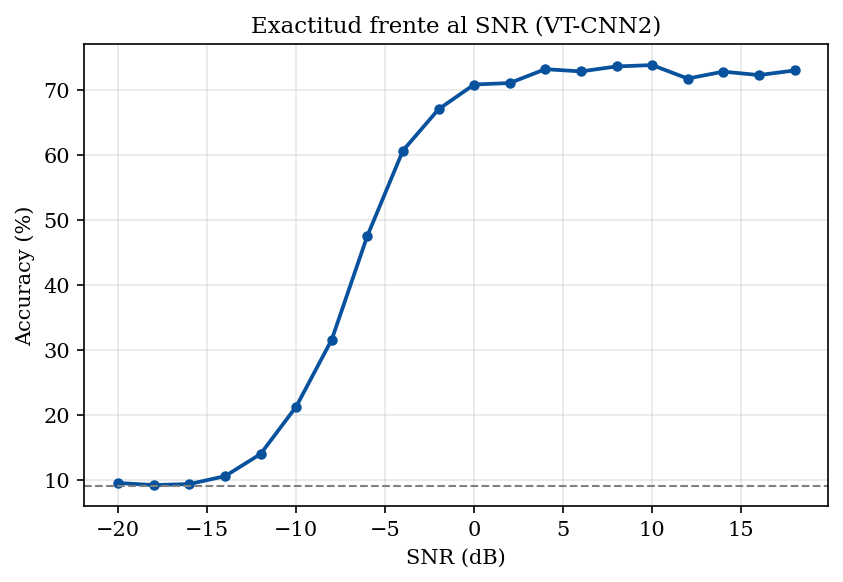

In [ ]:
# =====================================================================
# 6) Vista previa rápida en el notebook (no afecta los PDF guardados)
# =====================================================================
%matplotlib inline
# Reutilizamos las mismas rutinas para mostrar 4 figuras clave en pantalla.
import matplotlib.image as mpimg  # solo para confirmar que los archivos existen

for name in ["vtcnn2_loss.pdf", "vtcnn2_acc_vs_snr.pdf",
             "vtcnn2_confusion_global.pdf", "vtcnn2_metrics_by_snr.pdf"]:
    p = os.path.join(OUTDIR, name)
    print(("OK  " if os.path.isfile(p) else "FALTA ") + name +
          (f"  ({os.path.getsize(p)} bytes)" if os.path.isfile(p) else ""))

# Mostrar la curva de exactitud vs SNR directamente en pantalla
fig, ax = plt.subplots(figsize=(6.4, 4.0))
s = np.array(snrs); a = np.array([acc_by_snr[x] for x in snrs]) * 100
o = np.argsort(s)
ax.plot(s[o], a[o], "o-", color="#08519c", lw=1.8, markersize=4)
ax.axhline(100/11, color="gray", ls="--", lw=1)
ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Exactitud frente al SNR (VT-CNN2)"); ax.grid(alpha=0.3)
plt.show()


In [ ]:
# =====================================================================
# 7) Empaquetar y descargar (Google Colab)
# =====================================================================
import shutil
shutil.make_archive("figs_obj3", "zip", OUTDIR)
shutil.make_archive("resultados_csv", "zip", CSVDIR)
print("Creados: figs_obj3.zip  y  resultados_csv.zip")

# Opcional: copiar a Google Drive
# DEST = "/content/drive/MyDrive/Sync GD/TESIS/Colab/figs_obj3"
# shutil.copytree(OUTDIR, DEST, dirs_exist_ok=True)
# print("Copiado a:", DEST)

try:
    from google.colab import files
    files.download("figs_obj3.zip")
    files.download("resultados_csv.zip")
except Exception as e:
    print("Descarga automática no disponible (¿fuera de Colab?):", e)


Creados: figs_obj3.zip  y  resultados_csv.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>